### Section 4: Final Prediction Pipeline


In [7]:
import pandas as pd
import numpy as np
import joblib
import os

In [8]:
TEST_DATA_PATH = "test_data.csv"
SUBMISSION_PATH = "Group10_Generalization.csv"

# Models to load
# Clusters 0 and 5 are "Constant 0" and have no files.
MODEL_FILES = {
    1: "cluster1_stacking.joblib",
    2: "cluster2_stacking.joblib",
    3: "cluster3_stacking.joblib",
    4: "cluster4_stacking.joblib"
}

# Load Preprocessing & Cluster Predictor
cluster_pkg = joblib.load("cluster_id_predictor.joblib")
scaler = cluster_pkg["scaler"]
cluster_model = cluster_pkg["model"]
feature_names = cluster_pkg["features"]

print("Loaded Cluster Predictor and Scaler.")

# Load Subgroup Models
subgroup_models = {}
for c_id, filename in MODEL_FILES.items():
    if os.path.exists(filename):
        print(f"Loading model for Cluster {c_id}...")
        pkg = joblib.load(filename)
        subgroup_models[c_id] = pkg["model"]
    else:
        print(f"WARNING: Model file {filename} not found! Predictions for Cluster {c_id} will fail.")

Loaded Cluster Predictor and Scaler.
Loading model for Cluster 1...
Loading model for Cluster 2...
Loading model for Cluster 3...
Loading model for Cluster 4...


In [9]:
df_test = pd.read_csv(TEST_DATA_PATH)
print(f"\nLoaded Test Data. Shape: {df_test.shape}")

# Store Index for submission
test_indices = df_test["Index"]

# Select features and Scale
X_test_raw = df_test[feature_names]

X_test_scaled = scaler.transform(X_test_raw)

# Predict Cluster ID for each test company
print("Predicting Cluster IDs for test data...")
test_clusters = cluster_model.predict(X_test_scaled)


Loaded Test Data. Shape: (1012, 96)
Predicting Cluster IDs for test data...


In [10]:
# Generating Final Predictions
final_predictions = []
debug_counts = {i: 0 for i in range(6)} # Track how many companies go to each cluster

print("\nRouting test companies to subgroup models...")

for i in range(len(df_test)):
    c_id = test_clusters[i]
    row_index = test_indices.iloc[i]
    
    debug_counts[c_id] += 1
    
    
    if c_id in [0, 5]:
        pred = 0 # Constant prediction
    elif c_id in subgroup_models:
        # We need to extract the specific features that the model expects
        # Passing a 2D array (1 sample)
        sample = X_test_raw.iloc[[i]]
        pred = subgroup_models[c_id].predict(sample)[0]
    else:
        print(f"Warning: No model for Cluster {c_id}. Defaulting to 0.")
        pred = 0
        
    final_predictions.append(pred)


Routing test companies to subgroup models...


In [11]:
submission_df = pd.DataFrame({
    "Index": test_indices,
    "Bankrupt?": final_predictions
})

submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f"Total Predictions: {len(submission_df)}")
print(f"Predicted Bankruptcies: {sum(final_predictions)}")
print("\nCluster Distribution in Test Set:")
for c_id, count in sorted(debug_counts.items()):
    print(f"  Cluster {c_id}: {count} companies")

pct_bankrupt = (sum(final_predictions) / len(submission_df)) * 100
print(f"\nFinal Predicted Bankruptcy Rate: {pct_bankrupt:.2f}%")
if pct_bankrupt > 20:
    print("Prediction rate is > 20%.")
else:
    print("Prediction rate is within expected bounds.")

Total Predictions: 1012
Predicted Bankruptcies: 153

Cluster Distribution in Test Set:
  Cluster 0: 86 companies
  Cluster 1: 346 companies
  Cluster 2: 460 companies
  Cluster 3: 0 companies
  Cluster 4: 120 companies
  Cluster 5: 0 companies

Final Predicted Bankruptcy Rate: 15.12%
Prediction rate is within expected bounds.


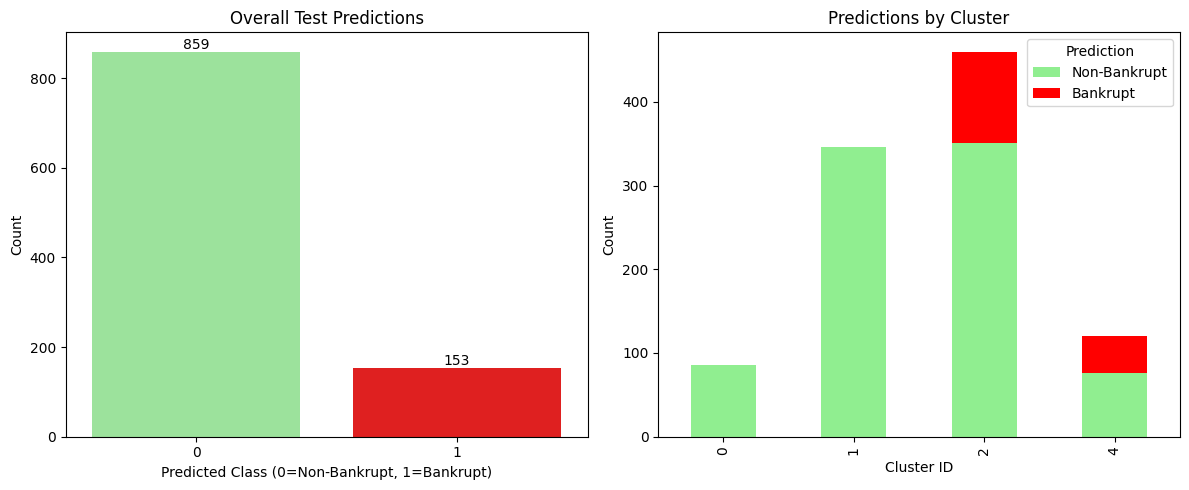

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax1 = sns.countplot(x=final_predictions, hue=final_predictions, palette=['lightgreen', 'red'], legend=False)
plt.title('Overall Test Predictions')
plt.xlabel('Predicted Class (0=Non-Bankrupt, 1=Bankrupt)')
plt.ylabel('Count')
for container in ax1.containers:
    ax1.bar_label(container)

plot_df = pd.DataFrame({
    'Cluster': test_clusters,
    'Prediction': final_predictions
})

plt.subplot(1, 2, 2)# Filter only for bankrupt predictions to see where they come from
# Or stack them directly
ct = pd.crosstab(plot_df['Cluster'], plot_df['Prediction'])
ct.plot(kind='bar', stacked=True, color=['lightgreen', 'red'], ax=plt.gca())
plt.title('Predictions by Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.legend(title='Prediction', labels=['Non-Bankrupt', 'Bankrupt'])

plt.tight_layout()
plt.savefig("generalization_summary.png")
plt.show()